## PA005 - High Value Customer Identification (Rankers)

## 0.0 Planejamento da Soluçao (IOT)

### Input

🎯 Definição do Projeto – Programa Rankers

1️⃣ Problema de Negócio

Identificar e selecionar os clientes mais valiosos da base para compor o programa **Rankers**, priorizando aqueles com maior impacto no faturamento e maior potencial de retenção.

O objetivo é concentrar esforços estratégicos nos clientes que mais contribuem para o crescimento sustentável do negócio.

---

2️⃣ Conjunto de Dados

A análise foi realizada com base em:

- 📊 Dados de vendas de um e-commerce online  
- 📆 Período analisado: 1 ano  

Esses dados permitem avaliar comportamento de compra, frequência, recência e geração de receita.

### Output

1️⃣ Indicação dos Participantes

Entrega de uma lista objetiva contendo:

- Identificação do cliente  
- Status: **É Ranker? (Sim/Não)**  

Essa lista será a base oficial do programa.

---

2️⃣ Relatório Executivo

O relatório deverá responder às principais perguntas de negócio:

- Quem são as pessoas elegíveis ao programa?
- Quantos clientes farão parte do grupo?
- Quais são as principais características desses clientes?
- Qual a porcentagem de contribuição no faturamento total?
- Qual a expectativa de faturamento para os próximos meses?
- Quais são as condições para elegibilidade?
- Quais são as condições para remoção do programa?
- Qual a garantia de que o programa é superior ao restante da base?
- Quais ações de marketing podem aumentar o faturamento?

### Tasks

1️⃣ Quem são as pessoas elegíveis ao programa?

Definição de Elegibilidade

**📈 Faturamento**
- Alto ticket médio  
- Alto Lifetime Value (LTV)  
- Baixa recência (compras recentes)  
- Alto basket size  
- Baixa probabilidade de churn  
- Alta propensão de compra  

**💰 Custo**
- Baixa taxa de devolução  

**⭐ Experiência de Compra**
- Alta média de avaliação  

---

2️⃣ Quantos clientes farão parte do grupo?

- Número total de clientes elegíveis  
- Percentual que representam dentro da base  

---

3️⃣ Quais as principais características desses clientes?

**👤 Perfil Demográfico**
- Idade  
- Localização  
- Gênero  

**🛒 Perfil Comportamental**
- Atributos identificados na clusterização  

---

4️⃣ Qual a porcentagem de contribuição no faturamento?

- Faturamento total do ano  
- Faturamento gerado pelo grupo Ranker  
- Participação percentual do grupo na receita  

---

5️⃣ Qual a expectativa de faturamento futuro?

- Análise de LTV do grupo Ranker  
- Análise de Cohort para projeção de receita  

---

6️⃣ Condições para elegibilidade

- Definição de periodicidade de avaliação (mensal, bimestral, trimestral)  
- Similaridade com o perfil médio do grupo Ranker  

---

7️⃣ Condições para remoção

- Reavaliação periódica  
- Desvio significativo dos indicadores de valor  

---

8️⃣ Garantia de superioridade do programa

- Teste A/B comparando Rankers vs. base geral  
- Testes estatísticos de validação de impacto  

---

9️⃣ Ações estratégicas de marketing

- Relacionamento personalizado (ex: visita à empresa)  
- Benefícios exclusivos  
- Descontos estratégicos  

# 0.0 Imports

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import inflection

import umap.umap_ as umap

from kneed import KneeLocator
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer
from matplotlib import pyplot as plt

## 0.1 Helper Functions

In [4]:
def vscode_settings():
    plt.style.use('bmh')
    
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 14
    plt.rcParams['font.family'] = 'DejaVu Sans'
    
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option('display.expand_frame_repr', False)
    
    sns.set_palette("Set2")

vscode_settings()       

In [5]:
def plot_settings():
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    # Base limpa
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Tamanho equilibrado
    plt.rcParams['figure.figsize'] = (14, 8)
    plt.rcParams['figure.dpi'] = 120
    
    # Fonte segura
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['font.size'] = 12
    
    # Grid mais leve
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'
    
    # Remove bordas desnecessárias
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Paleta mais profissional
    sns.set_palette("colorblind")
    
    # Pandas display
    pd.options.display.max_columns = None
    pd.options.display.max_rows = 200
    pd.set_option('display.expand_frame_repr', False)

plot_settings()

## 0.2 Load Dataset

In [6]:
df_raw = (
    pd.read_csv(
        '../data/Ecommerce.csv',
        encoding='latin1'
    )
    .loc[:, lambda df: ~df.columns.str.contains('^Unnamed')]
)

In [7]:
df_raw.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,29-Nov-16,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,29-Nov-16,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,29-Nov-16,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,29-Nov-16,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,29-Nov-16,3.39,17850.0,United Kingdom


# 1.0 Data Description

In [8]:
df1 = df_raw

## 1.1 Rename columns

In [9]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [10]:
cols_old = df1.columns

snakecase = lambda x: inflection.underscore(x)
cols_new = list(map(snakecase, cols_old))

df1.columns = cols_new
df1.sample()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
13079,537418,22728,ALARM CLOCK BAKELIKE PINK,1,4-Dec-16,3.75,17884.0,United Kingdom


## 1.2 Data Dimensions

In [11]:
df1.shape

(541909, 8)

## 1.3 Data types

In [12]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

## 1.4 Check NA

In [13]:
df1.isna().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
dtype: int64

## 1.5 Replace NA

In [14]:
# remove NA - Ciclo 1

df1 = df1.dropna(subset=['description', 'customer_id'])
print('Removed data: {:.2%}'.format( 1-(df1.shape[0] / df_raw.shape[0])))

Removed data: 24.93%


In [15]:
df1.isna().sum()

invoice_no      0
stock_code      0
description     0
quantity        0
invoice_date    0
unit_price      0
customer_id     0
country         0
dtype: int64

## 1.6 Change dtypes

In [16]:
df1.dtypes

invoice_no          str
stock_code          str
description         str
quantity          int64
invoice_date        str
unit_price      float64
customer_id     float64
country             str
dtype: object

In [17]:
# invoice date

df1['invoice_date'] = pd.to_datetime(df1['invoice_date'], format='%d-%b-%y')

#customer_id

df1['customer_id']  = df1['customer_id'].astype(int)

In [18]:
df1.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
dtype: object

## 1.7 Descriptive Statistics

In [19]:
df1.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              int64
country                    str
dtype: object

In [20]:
num_attributes = df1.select_dtypes(include=['int64', 'float64'])
cat_attributes = df1.select_dtypes(exclude=['int64', 'float64', 'datetime64'])

### 1.7.1 Numerical Attributes

In [21]:
# central tendency - mean, median
ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T 
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T 

# dispersion - std, min, max, range, skew, kurtosis
d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(np.min)).T
d3 = pd.DataFrame (num_attributes.apply(np.max)).T
d4 = pd.DataFrame (num_attributes.apply( lambda x: x.max() - x.min())).T
d5 = pd.DataFrame (num_attributes.apply( lambda x: x.skew())).T
d6 = pd.DataFrame (num_attributes.apply( lambda x: x.kurtosis())).T

# concatenate
m = pd.concat ([d2,d3,d4,ct1,ct2,d1,d5,d6]).T.reset_index()
m.columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis']
m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,quantity,-80995.0,80995.0,161990.0,12.061303,5.00,248.693064,0.182663,94317.563673
1,unit_price,0.0,38970.0,38970.0,3.460471,1.95,69.315077,452.219019,246924.542988
2,customer_id,12346.0,18287.0,5941.0,15287.690570,15152.00,1713.598197,0.029835,-1.179982


### <font color = 'red'>1.7.1.1  Numerical Attributes - Investigating

1 - Quantidade minima negativa? Devolucao

2 - Quantidade maxima muito grande? Outlier, std elevado

3 - Preco com valor minimo de 0? Brinde?

### 1.7.2 Categorical Attributes

In [22]:
cat_attributes.head()

,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
1,536365,71053,WHITE METAL LANTERN,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom


In [23]:
# INVOICE_NO

#cat_attributes['invoice_no'].astype(int)
#invalid literal for int() with base 10: 'C536379'

# filtra invoices que possuem qualquer caractere não numérico
df_matches = cat_attributes[
    cat_attributes['invoice_no'].str.contains(r'[^0-9]', regex=True, na=False)
].drop_duplicates(subset='invoice_no')

# quantidade de invoices
quantidade = len(df_matches)

# prefixos de letras no início do invoice
prefixos = sorted(
    set(
        df_matches['invoice_no'].str.extract(r'^([A-Za-z]+)', expand=False).dropna()
    )
)

print('Prefixos encontrados: {}'.format(prefixos))
print('Quantidade de invoice com letras: {}'.format(quantidade))

df_matches

Prefixos encontrados: ['C']
Quantidade de invoice com letras: 3654


,invoice_no,stock_code,description,country
141,C536379,D,Discount,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,United Kingdom
1441,C536543,22632,HAND WARMER RED RETROSPOT,United Kingdom
...,...,...,...,...
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",United Kingdom
540448,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,United Kingdom
541541,C581499,M,Manual,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,United Kingdom


In [24]:
# STOCK_CODE

# filtra stock_code que possuem letras
df_matches = cat_attributes[
    cat_attributes['stock_code'].str.contains(r'[A-Za-z]', regex=True, na=False)
].drop_duplicates(subset='stock_code')

# extrai blocos de letras
prefixos = sorted(
    set(
        df_matches['stock_code'].str.extract(r'^([A-Za-z]+)', expand=False).dropna()
    )
)

quantidade = len(prefixos)

print('Prefixos únicos encontrados: {}'.format(prefixos))
print('Quantidade de prefixos: {}'.format(quantidade))

df_matches

Prefixos únicos encontrados: ['BANK', 'C', 'CRUK', 'D', 'DOT', 'M', 'PADS', 'POST']
Quantidade de prefixos: 8


,invoice_no,stock_code,description,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,United Kingdom
45,536370,POST,POSTAGE,France
...,...,...,...,...
527060,580691,90214O,"LETTER ""O"" BLING KEY RING",United Kingdom
527064,580691,90214T,"LETTER ""T"" BLING KEY RING",United Kingdom
527065,580691,90214U,"LETTER ""U"" BLING KEY RING",United Kingdom
527067,580691,90214W,"LETTER ""W"" BLING KEY RING",United Kingdom


# 2.0 Feature Filtering

In [25]:
df2 = df1.copy()

In [26]:
df_purchase = df2[~df2['invoice_no'].str.startswith('C')].copy()
df_returns = df2[df2['invoice_no'].astype(str).str.startswith('C')].copy()

In [27]:
df_returns.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
141,C536379,D,Discount,-1,2016-11-29,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2016-11-29,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2016-11-29,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2016-11-29,0.29,17548,United Kingdom


In [28]:
df_purchase.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2016-11-29,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2016-11-29,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2016-11-29,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2016-11-29,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2016-11-29,3.39,17850,United Kingdom


# 3.0 Feature Engineering

In [29]:
df3 = df2.copy()

## 3.1 Feature Creation

In [30]:
# data reference
df_ref = df3.drop(['invoice_no', 'stock_code', 'description', ''
                    'quantity', 'invoice_date', 'unit_price', 'country'], axis=1).drop_duplicates().reset_index(drop=True)
df_ref.head(10)

,customer_id
0,17850
1,13047
2,12583
3,13748
4,15100
5,15291
6,14688
7,17809
8,15311
9,14527


In [31]:
# Gross Revenue quantity * price = faturamento
df_purchase['gross_revenue'] = df_purchase['quantity'] * df_purchase['unit_price']

# Monetary
df_monetary = (
    df_purchase[['customer_id','gross_revenue']]
    .groupby('customer_id')
    .sum()
    .reset_index()
)

df_ref = pd.merge(df_ref, df_monetary, on='customer_id', how='left')


# Recency - Last day purchase
df_recency = (
    df_purchase[['customer_id', 'invoice_date']]
    .groupby('customer_id')
    .max()
    .reset_index()
)

df_recency['recency_days'] = (
    df_purchase['invoice_date'].max() - df_recency['invoice_date']
).dt.days

df_recency = df_recency[['customer_id', 'recency_days']].copy()

df_ref = pd.merge(df_ref, df_recency, on='customer_id', how='left')


# Frequency - Frequência de pedidos
df_freq = (
    df_purchase
    .groupby('customer_id')['invoice_no']
    .nunique()
    .reset_index()
    .rename(columns={'invoice_no': 'frequency'})
)

df_ref = pd.merge(df_ref, df_freq, on='customer_id', how='left')


# AVG ticket
df_order_value = (
    df_purchase
    .groupby(['customer_id','invoice_no'])['gross_revenue']
    .sum()
    .reset_index()
)

df_avg_ticket = (
    df_order_value
    .groupby('customer_id')['gross_revenue']
    .mean()
    .reset_index()
    .rename(columns={'gross_revenue':'avg_ticket'})
)

df_ref = pd.merge(df_ref, df_avg_ticket, on='customer_id', how='left')

In [32]:
df_returns['return_revenue'] = df_returns['quantity'] * df_returns['unit_price']

df_return_value = (
    df_returns.groupby('customer_id')['return_revenue']
    .sum()
    .abs()
    .reset_index()
    .rename(columns={'return_revenue':'return_value'})
)

df_return_orders = (
    df_returns.groupby('customer_id')['invoice_no']
    .nunique()
    .reset_index()
    .rename(columns={'invoice_no':'return_orders'})
)

df_returns_features = pd.merge(
    df_return_value,
    df_return_orders,
    on='customer_id',
    how='outer'
)

df_ref = pd.merge(
    df_ref,
    df_returns_features,
    on='customer_id',
    how='left'
)


In [33]:
df_ref.isna().sum()

customer_id         0
gross_revenue      33
recency_days       33
frequency          33
avg_ticket         33
return_value     2783
return_orders    2783
dtype: int64

In [34]:
df_ref = df_ref[df_ref['gross_revenue'].notna()]

df_ref[['return_value','return_orders']] = df_ref[['return_value','return_orders']].fillna(0)

In [35]:
# CRIAR O RETURN RATE COM AS DEVOLUCOES E FREQUENCIA

df_ref['return_rate'] = df_ref['return_orders'] / df_ref['frequency']

# CRIAR O RETURN RATE VALUE RATIO
df_ref['return_value_ratio'] = (
    df_ref['return_value'] / df_ref['gross_revenue']
)

df_ref['return_value_ratio'] = df_ref['return_value_ratio'].fillna(0)

In [36]:
df_ref.isna().sum()

customer_id           0
gross_revenue         0
recency_days          0
frequency             0
avg_ticket            0
return_value          0
return_orders         0
return_rate           0
return_value_ratio    0
dtype: int64

In [37]:
df_ref.head(20)

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio
0,17850,5391.21,372.0,34.0,158.565000,102.58,1.0,0.029412,0.019027
1,13047,3237.54,31.0,10.0,323.754000,158.44,8.0,0.800000,0.048938
2,12583,7281.38,2.0,15.0,485.425333,94.04,3.0,0.200000,0.012915
3,13748,948.25,95.0,5.0,189.650000,0.00,0.0,0.000000,0.000000
4,15100,876.00,333.0,3.0,292.000000,240.90,3.0,1.000000,0.275000
5,15291,4668.30,25.0,15.0,311.220000,71.79,5.0,0.333333,0.015378
6,14688,5630.87,7.0,21.0,268.136667,523.49,6.0,0.285714,0.092968
7,17809,5411.91,16.0,12.0,450.992500,784.29,3.0,0.250000,0.144919
8,15311,60767.90,0.0,91.0,667.779121,1348.56,27.0,0.296703,0.022192
9,14527,8508.82,2.0,55.0,154.705818,797.44,31.0,0.563636,0.093719


### <font color='red'>3.1.1 NA Investigate

In [38]:
clientes_nan = df_ref[df_ref['gross_revenue'].isna()]['customer_id']

clientes_nan.head()
len(clientes_nan)

0

In [39]:
df2[df2['customer_id'].isin(clientes_nan)]

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country


1 Clientes possuem apenas devolucao e nenhuma compra. Nao representam nenhuma informacao

2 Preenchido com 0 os clientes que nao devolveram nenhum produto

### <font color='red'> VALIDAR STOCK_CODE, ATE O MOMENTO CONSIDERADO DEVOLUCOES COMO COMPORTAMENTO. POREM VERIFICADO QUE NO STOCK_CODE HÁ CONDICIONAIS

# 4.0 EDA

In [40]:
df4 = df_ref.copy()

# 5.0 Data Preparation

In [78]:
df5 = df4.copy()

In [79]:
df5.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio
0,17850,5391.21,372.0,34.0,158.565000,102.58,1.0,0.029412,0.019027
1,13047,3237.54,31.0,10.0,323.754000,158.44,8.0,0.800000,0.048938
2,12583,7281.38,2.0,15.0,485.425333,94.04,3.0,0.200000,0.012915
3,13748,948.25,95.0,5.0,189.650000,0.00,0.0,0.000000,0.000000
4,15100,876.00,333.0,3.0,292.000000,240.90,3.0,1.000000,0.275000


In [80]:
from sklearn.preprocessing import MinMaxScaler
ss = MinMaxScaler()

features = [
    'gross_revenue',
    'recency_days',
    'frequency',
    'avg_ticket',
    'return_value'
]

X_scaled = df5.copy()

X_scaled[features] = ss.fit_transform(X_scaled[features])

In [81]:
X_scaled.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio
0,17850,0.019240,0.997319,0.157895,0.001882,0.000609,1.0,0.029412,0.019027
1,13047,0.011554,0.083110,0.043062,0.003843,0.000940,8.0,0.800000,0.048938
2,12583,0.025986,0.005362,0.066986,0.005763,0.000558,3.0,0.200000,0.012915
3,13748,0.003384,0.254692,0.019139,0.002251,0.000000,0.0,0.000000,0.000000
4,15100,0.003126,0.892761,0.009569,0.003466,0.001430,3.0,1.000000,0.275000


# 6.0 Feature Selection

# 7.0 Hyperparameter Fine-Tunning

In [82]:
X = X_scaled.drop(columns=['customer_id'])

In [83]:
X.head()

,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio
0,0.019240,0.997319,0.157895,0.001882,0.000609,1.0,0.029412,0.019027
1,0.011554,0.083110,0.043062,0.003843,0.000940,8.0,0.800000,0.048938
2,0.025986,0.005362,0.066986,0.005763,0.000558,3.0,0.200000,0.012915
3,0.003384,0.254692,0.019139,0.002251,0.000000,0.0,0.000000,0.000000
4,0.003126,0.892761,0.009569,0.003466,0.001430,3.0,1.000000,0.275000


In [84]:
clusters = [2,3,4,5,6,7,8,9,10,11]

## 7.1 Within-Cluster Sum of Square (WSS)

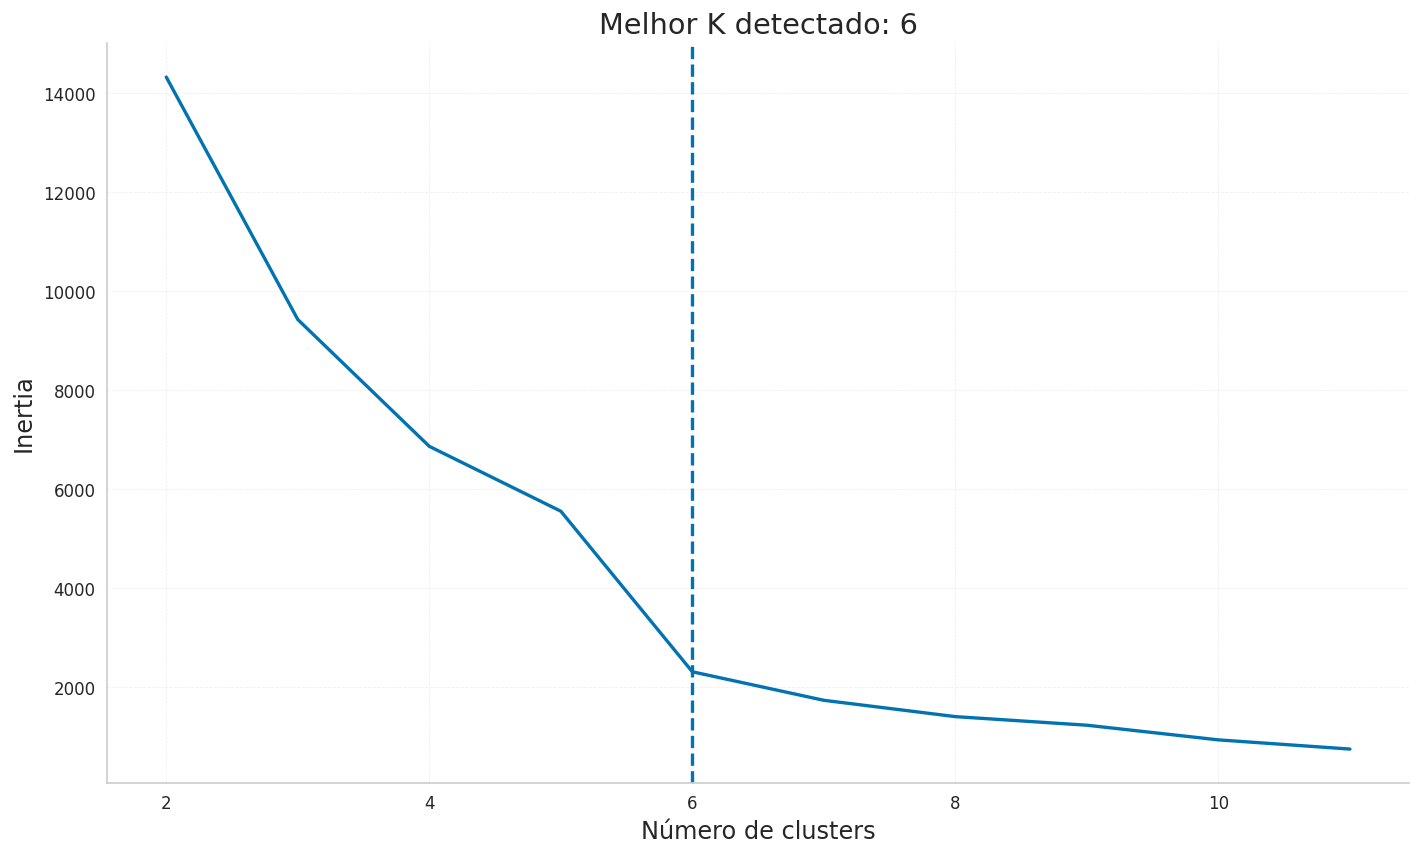

In [85]:
inertia = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Detectando o cotovelo
knee = KneeLocator(clusters, inertia, curve="convex", direction="decreasing")
best_k = knee.knee

# Plot
plt.plot(clusters, inertia)
plt.axvline(best_k, linestyle="--")
plt.xlabel("Número de clusters")
plt.ylabel("Inertia")
plt.title(f"Melhor K detectado: {best_k}")
plt.show()

## 7.2 Silhouette Score

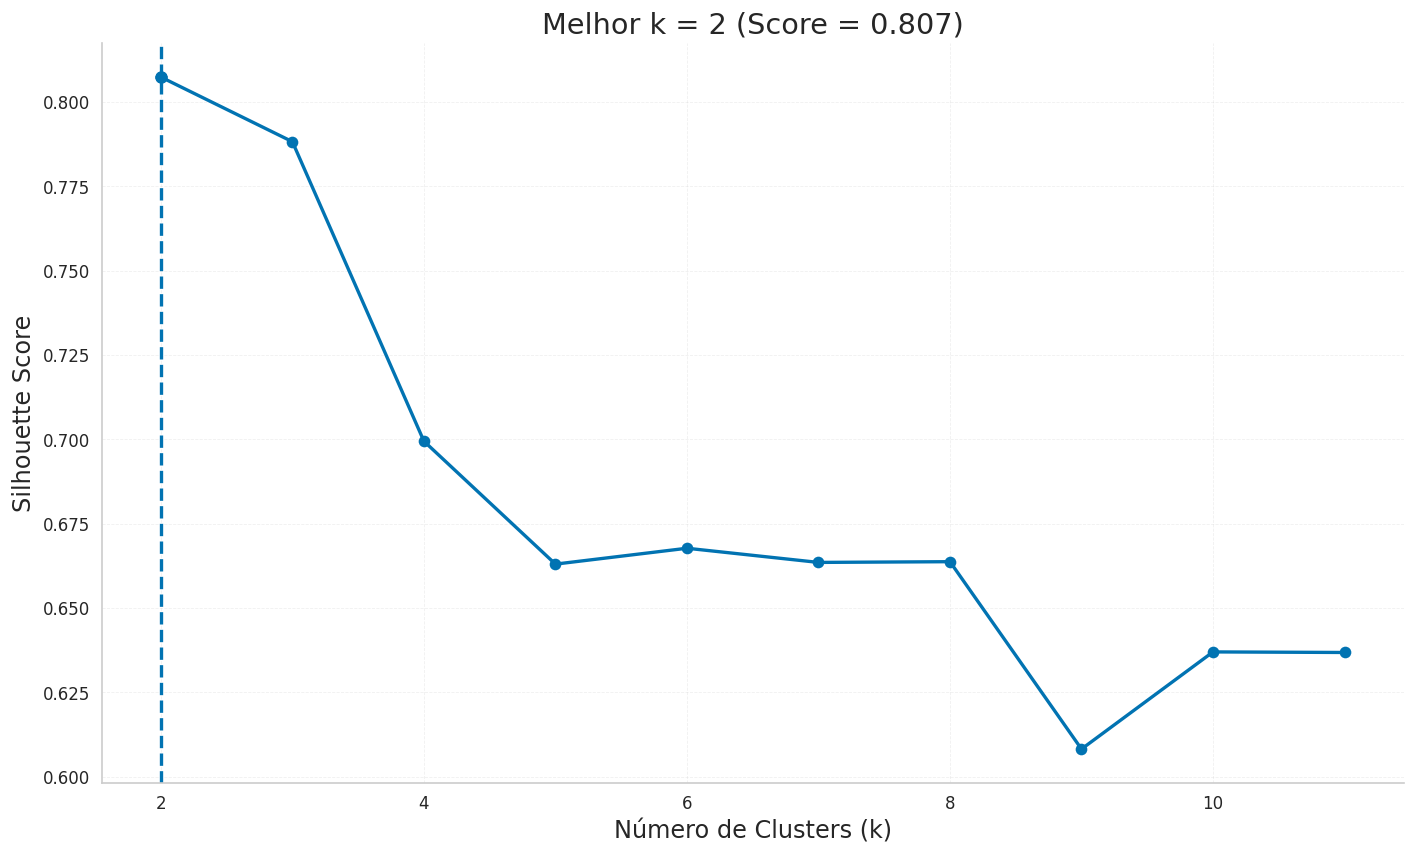

In [52]:
sil_scores = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    sil_scores.append(silhouette_score(X, labels))

# Melhor k (maior silhouette)
best_index = np.argmax(sil_scores)
best_k = list(clusters)[best_index]
best_score = sil_scores[best_index]

# Plot
plt.plot(clusters, sil_scores, marker='o')
plt.axvline(best_k, linestyle='--')
plt.scatter(best_k, best_score)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title(f"Melhor k = {best_k} (Score = {best_score:.3f})")
plt.show()

### 7.2.1 Silhouette Analysis

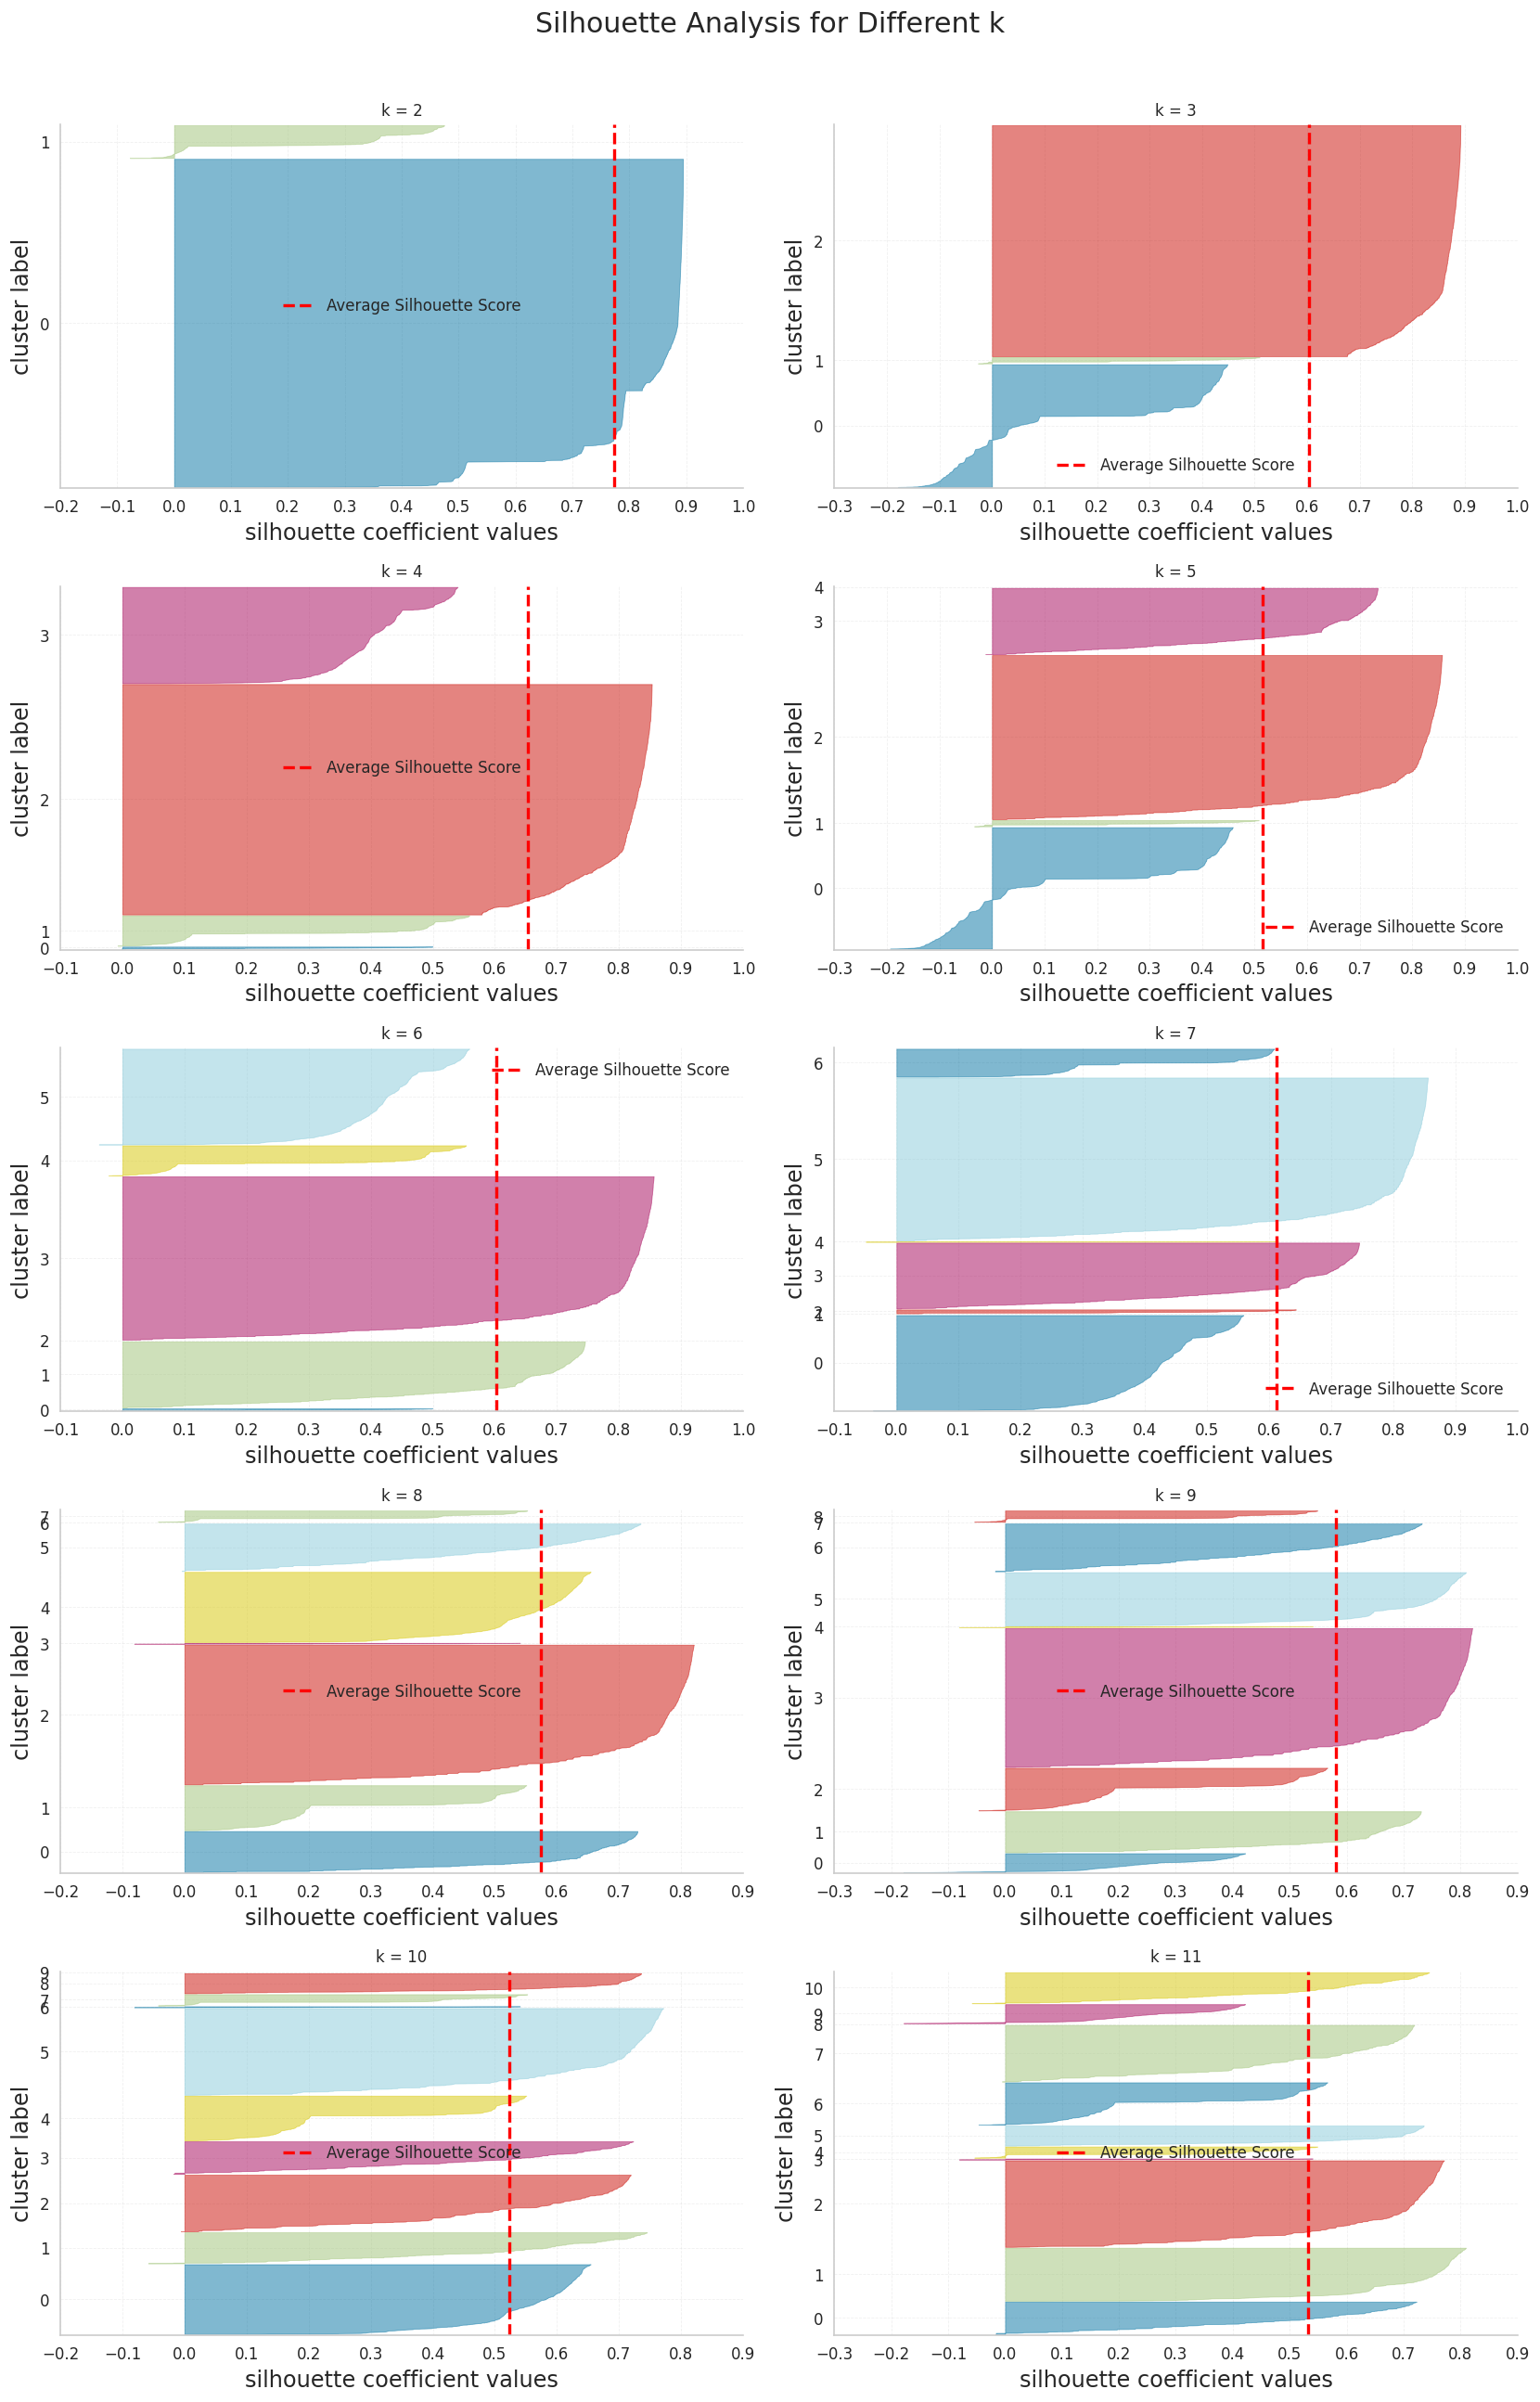

In [53]:
clusters = [2,3,4,5,6,7,8,9,10,11]

fig, ax = plt.subplots(5, 2, figsize=(14, 22))

for i, k in enumerate(clusters):
    
    km = KMeans(
        n_clusters=k,
        init='random',
        n_init=10,
        max_iter=100,
        random_state=42
    )
    
    row = i // 2
    col = i % 2
    
    visualizer = SilhouetteVisualizer(
        km,
        colors='yellowbrick',
        ax=ax[row][col],
        force_model=True
    )
    
    visualizer.fit(X)
    visualizer.finalize()
    
    ax[row][col].set_title(f"k = {k}", fontsize=10)

fig.suptitle("Silhouette Analysis for Different k", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 8.0 Model Training

## 8.1 KMeans

In [86]:
k = 6
model = KMeans(init='random', n_clusters=k, n_init=10, max_iter=300)

model.fit(X)

labels = model.labels_

## 8.2 Cluster Validation

In [87]:
# WSS

print('WSS: {}'.format(model.inertia_))

# Silhouette
print('Silhouette: {}'.format(silhouette_score(X, labels, metric='euclidean')))

WSS: 4353.422917763643
Silhouette: 0.601603873563622


# 9.0 Cluster Analysis

In [88]:
df5['cluster'] = labels
df5.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio,cluster
0,17850,5391.21,372.0,34.0,158.565000,102.58,1.0,0.029412,0.019027,5
1,13047,3237.54,31.0,10.0,323.754000,158.44,8.0,0.800000,0.048938,2
2,12583,7281.38,2.0,15.0,485.425333,94.04,3.0,0.200000,0.012915,2
3,13748,948.25,95.0,5.0,189.650000,0.00,0.0,0.000000,0.000000,0
4,15100,876.00,333.0,3.0,292.000000,240.90,3.0,1.000000,0.275000,2


## 9.1 Visualization - Knife

/home/pollon/.pyenv/versions/3.11.8/envs/pa005_rankers/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


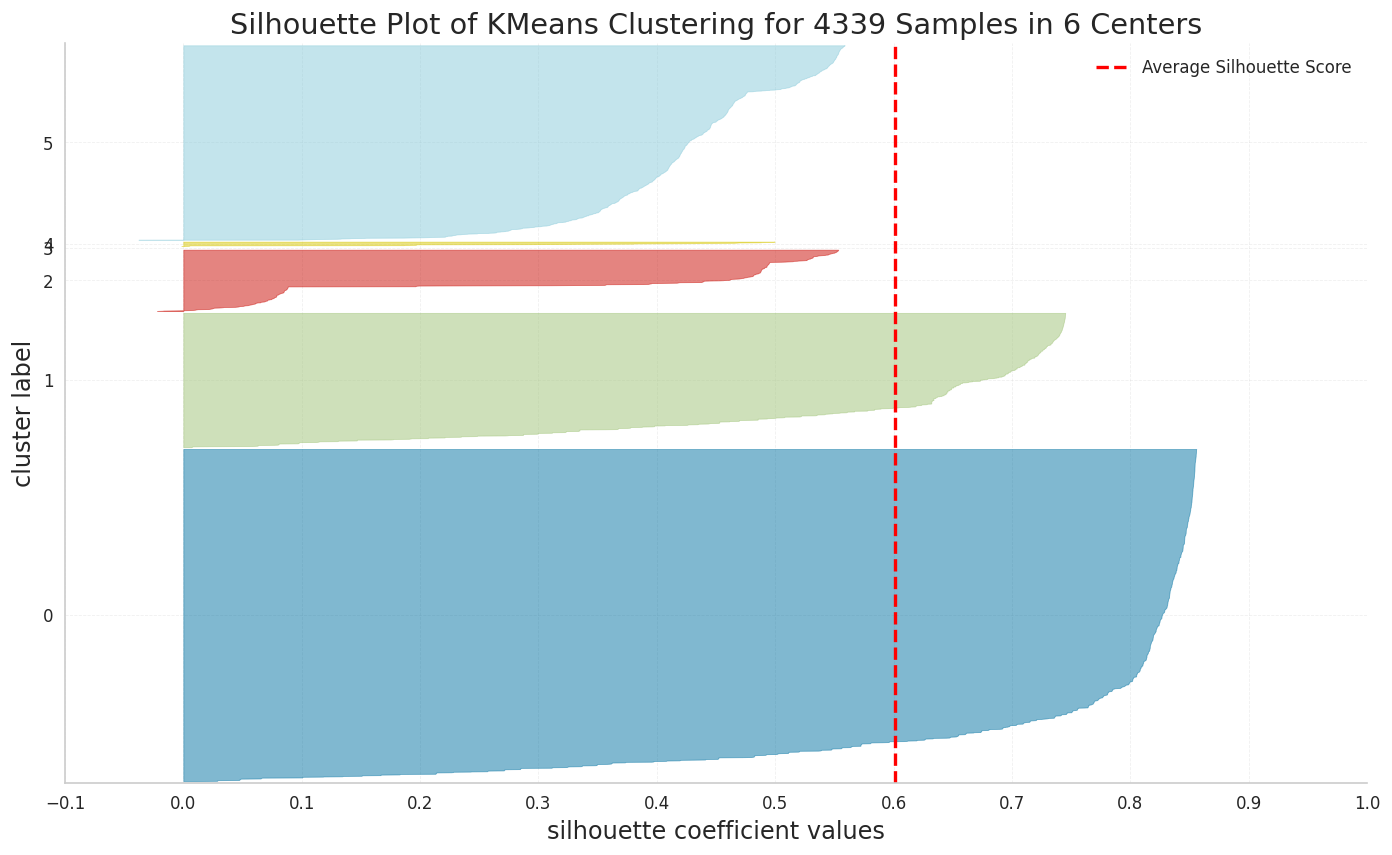

In [89]:
visualizer = SilhouetteVisualizer(model, colors='yellowbrick', force_model=True)
visualizer.fit(X)
visualizer.finalize()

## 9.1.2 Visualization - 2d plot

In [90]:
df5.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio,cluster
0,17850,5391.21,372.0,34.0,158.565000,102.58,1.0,0.029412,0.019027,5
1,13047,3237.54,31.0,10.0,323.754000,158.44,8.0,0.800000,0.048938,2
2,12583,7281.38,2.0,15.0,485.425333,94.04,3.0,0.200000,0.012915,2
3,13748,948.25,95.0,5.0,189.650000,0.00,0.0,0.000000,0.000000,0
4,15100,876.00,333.0,3.0,292.000000,240.90,3.0,1.000000,0.275000,2


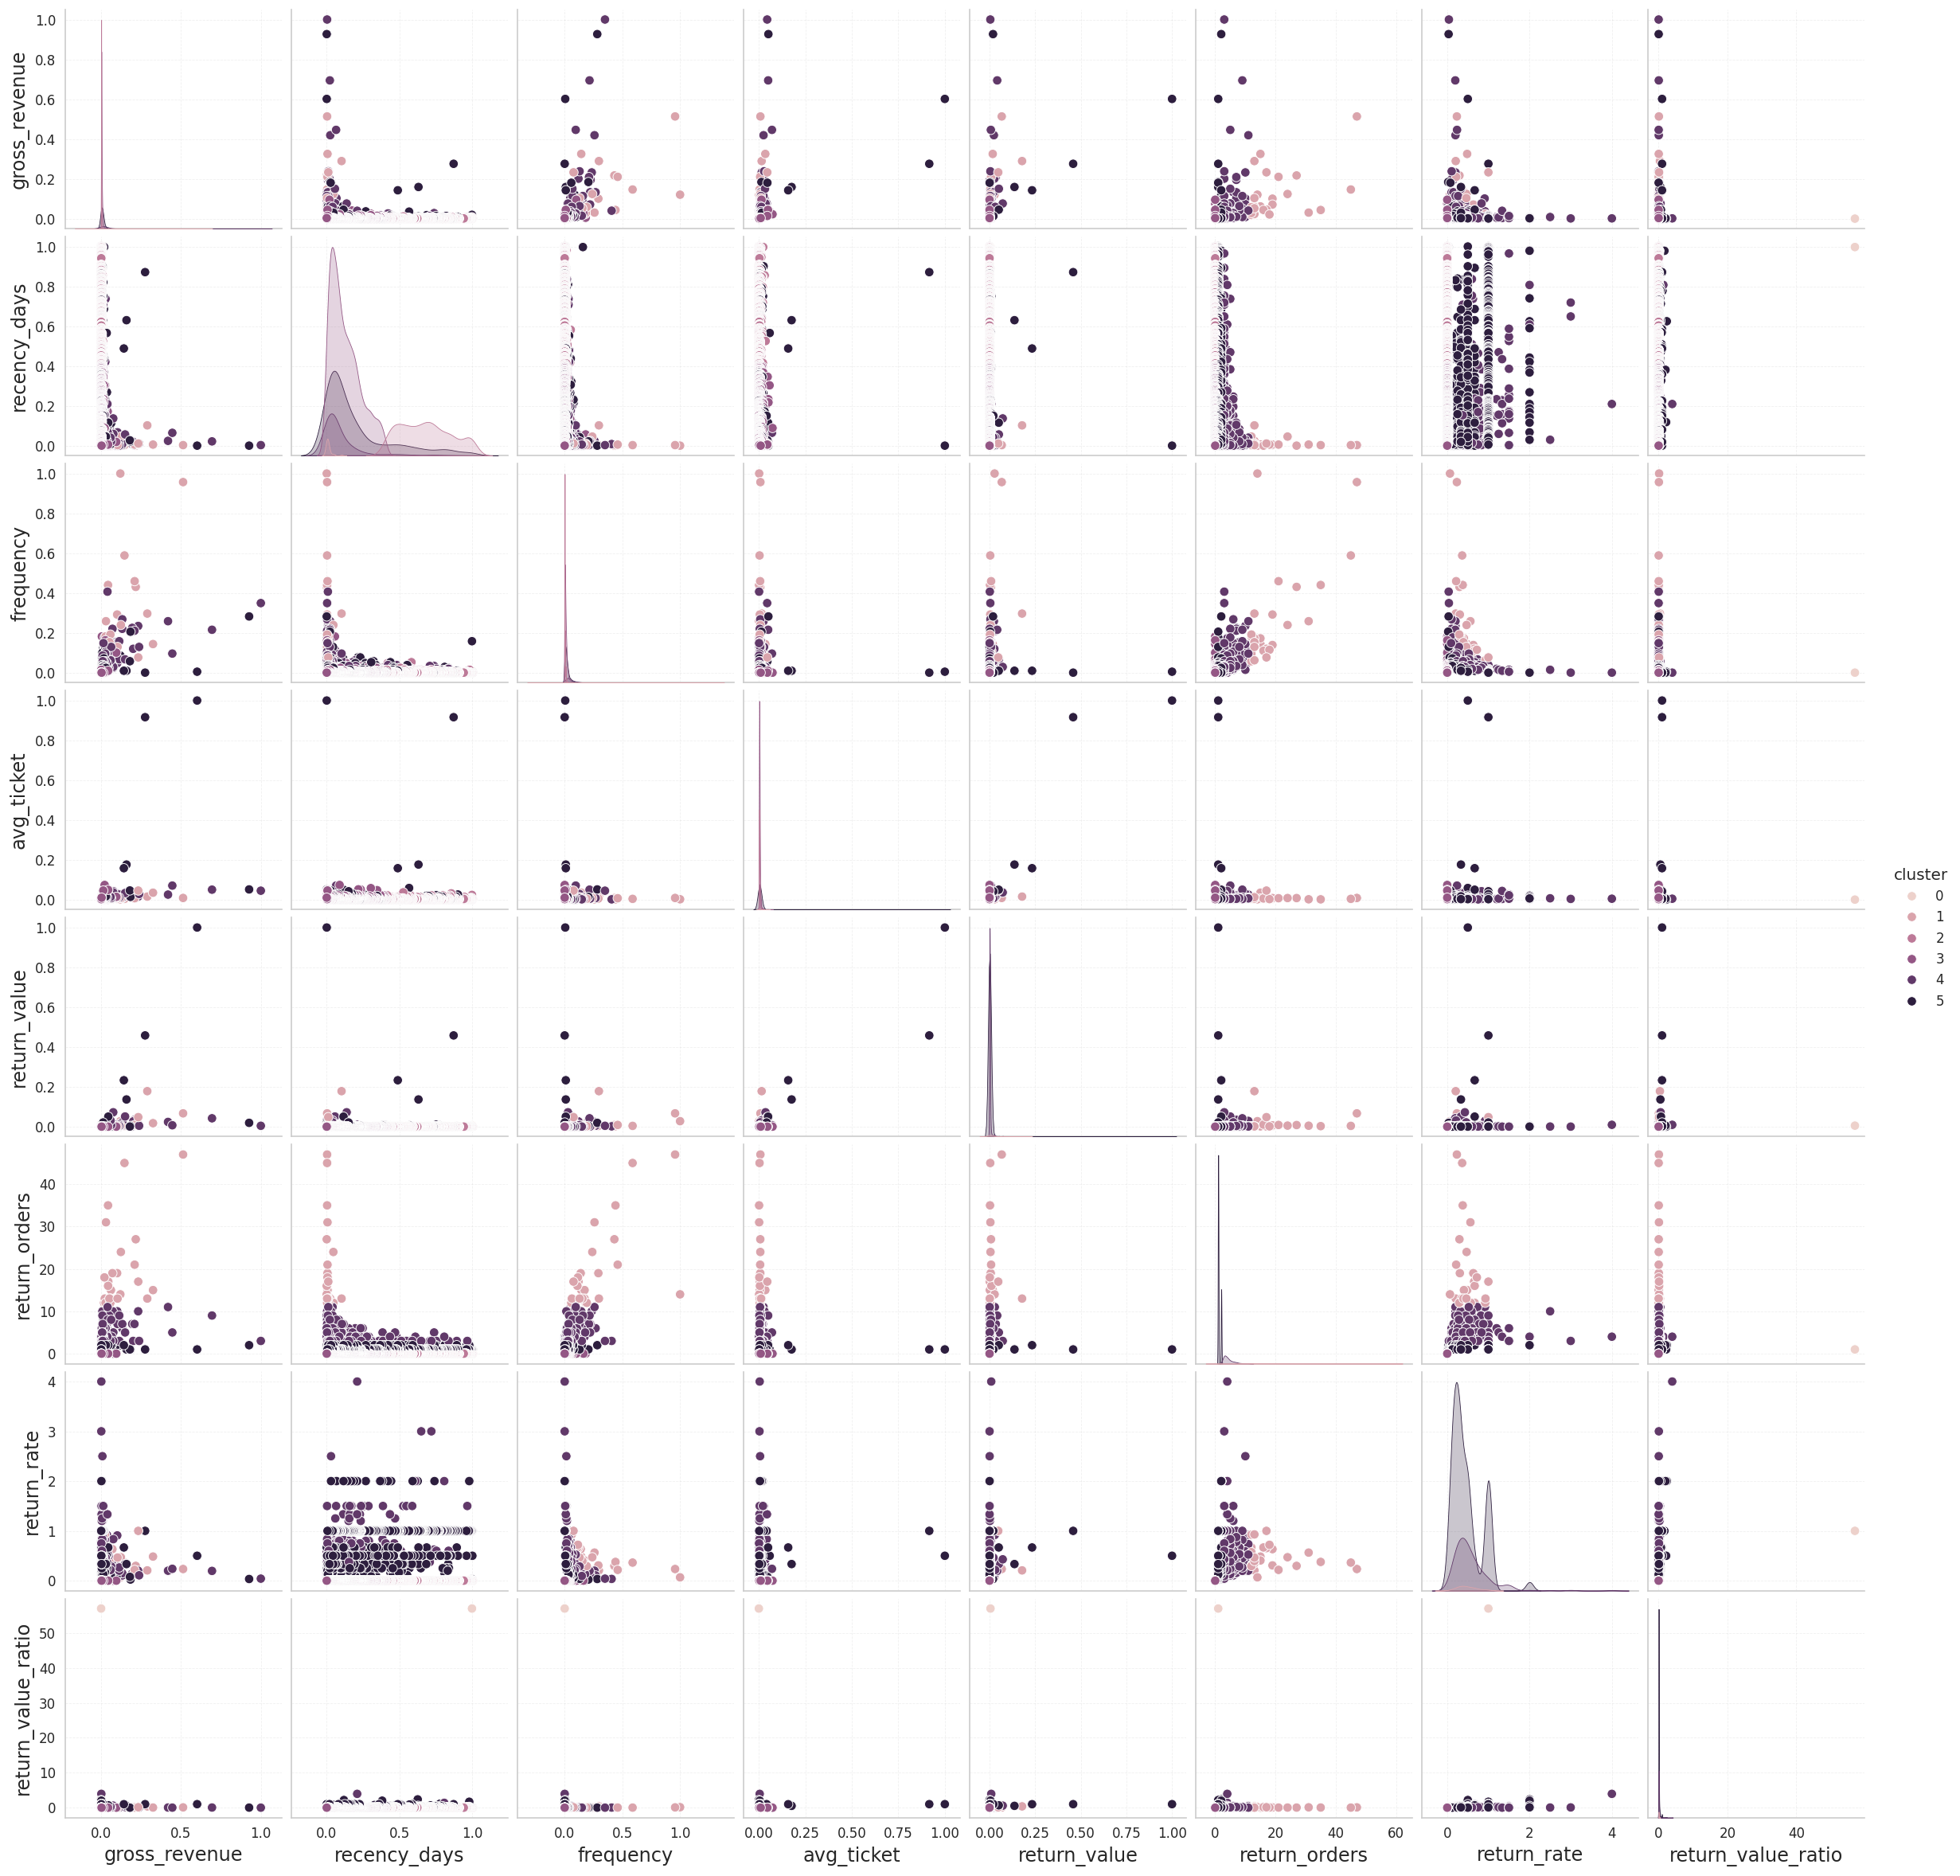

In [ ]:
df_viz = df5.drop(columns='customer_id')
sns.pairplot(df_viz, hue='cluster');

## 9.1.3 Visualization - UMAP

In [91]:
X.head()

,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio
0,0.019240,0.997319,0.157895,0.001882,0.000609,1.0,0.029412,0.019027
1,0.011554,0.083110,0.043062,0.003843,0.000940,8.0,0.800000,0.048938
2,0.025986,0.005362,0.066986,0.005763,0.000558,3.0,0.200000,0.012915
3,0.003384,0.254692,0.019139,0.002251,0.000000,0.0,0.000000,0.000000
4,0.003126,0.892761,0.009569,0.003466,0.001430,3.0,1.000000,0.275000


/home/pollon/.pyenv/versions/3.11.8/envs/pa005_rankers/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: xlabel='embedding_x', ylabel='embedding_y'>

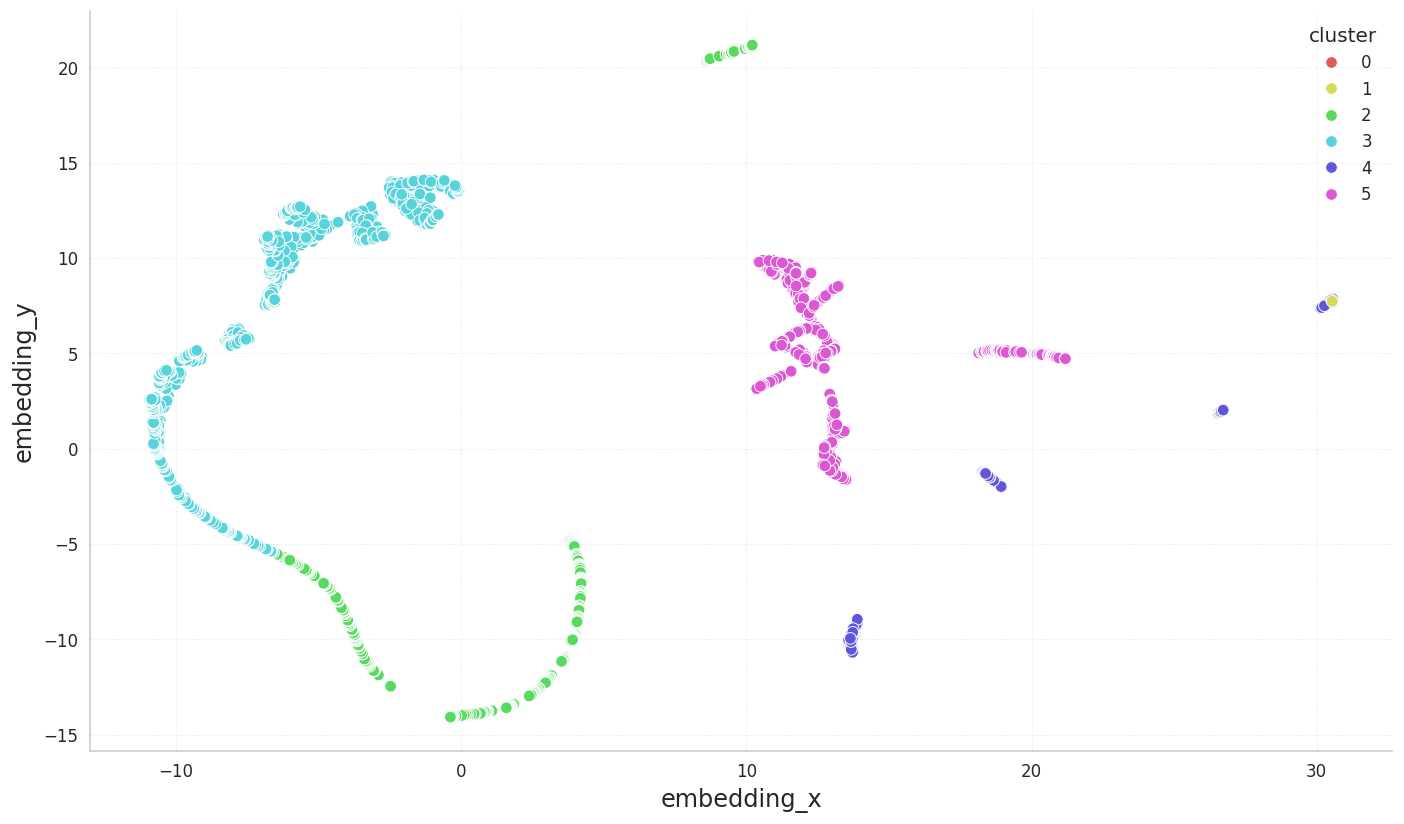

In [73]:
reducer = umap.UMAP(n_neighbors=80, random_state=42)
embedding = reducer.fit_transform(X)

# embedding
df_viz['embedding_x'] = embedding[:, 0]
df_viz['embedding_y'] = embedding[:, 1]

# plor
sns.scatterplot(x='embedding_x', y='embedding_y', hue='cluster', 
                    palette=sns.color_palette('hls', n_colors=len(df_viz['cluster'].unique())), data=df_viz)

## 9.2 Cluster Profile

In [196]:
#### Implementar PCA para decidir pesos das features/Substituir ticket médio por LTV

In [92]:
df5.head()

,customer_id,gross_revenue,recency_days,frequency,avg_ticket,return_value,return_orders,return_rate,return_value_ratio,cluster
0,17850,5391.21,372.0,34.0,158.565000,102.58,1.0,0.029412,0.019027,5
1,13047,3237.54,31.0,10.0,323.754000,158.44,8.0,0.800000,0.048938,2
2,12583,7281.38,2.0,15.0,485.425333,94.04,3.0,0.200000,0.012915,2
3,13748,948.25,95.0,5.0,189.650000,0.00,0.0,0.000000,0.000000,0
4,15100,876.00,333.0,3.0,292.000000,240.90,3.0,1.000000,0.275000,2


In [93]:
df_cluster = (
    df5
        .groupby('cluster')
        .agg(
            customer_count      = ('customer_id', 'nunique'),
            total_gross_revenue = ('gross_revenue', 'sum'),
            avg_gross_revenue   = ('gross_revenue', 'mean'),
            avg_recency_days    = ('recency_days', 'mean'),
            avg_frequency       = ('frequency', 'mean'),
            avg_ticket          = ('avg_ticket', 'mean'),
            avg_return_rate     = ('return_rate', 'mean')
        )
        .reset_index()
)

df_cluster['perc_revenue'] = (
    100 * df_cluster['total_gross_revenue']
    / df_cluster['total_gross_revenue'].sum()
)

df_cluster_display = df_cluster.round(2)

df_rank = df_cluster_display.copy()

# Normalização
df_rank['norm_ticket'] = (
    (df_rank['avg_gross_revenue'] - df_rank['avg_gross_revenue'].min()) /
    (df_rank['avg_gross_revenue'].max() - df_rank['avg_gross_revenue'].min())
)

df_rank['norm_freq'] = (
    (df_rank['avg_frequency'] - df_rank['avg_frequency'].min()) /
    (df_rank['avg_frequency'].max() - df_rank['avg_frequency'].min())
)

df_rank['norm_recency'] = 1 - (
    (df_rank['avg_recency_days'] - df_rank['avg_recency_days'].min()) /
    (df_rank['avg_recency_days'].max() - df_rank['avg_recency_days'].min())
)

df_rank['norm_return'] = 1 - (
    (df_rank['avg_return_rate'] - df_rank['avg_return_rate'].min()) /
    (df_rank['avg_return_rate'].max() - df_rank['avg_return_rate'].min())
)

# Penalização por tamanho (clusters muito grandes perdem ponto)
df_rank['size_penalty'] = (
    (df_rank['customer_count'] - df_rank['customer_count'].min()) /
    (df_rank['customer_count'].max() - df_rank['customer_count'].min())
)

# Score final
df_rank['score'] = (
    df_rank['norm_ticket'] * 0.45 +
    df_rank['norm_freq'] * 0.25 +
    df_rank['norm_recency'] * 0.20 +
    df_rank['norm_return'] * 0.10 -
    df_rank['size_penalty'] * 0.20
)

df_rank = df_rank.sort_values('score', ascending=False).reset_index(drop=True)
df_rank

,cluster,customer_count,total_gross_revenue,avg_gross_revenue,avg_recency_days,avg_frequency,avg_ticket,avg_return_rate,perc_revenue,norm_ticket,norm_freq,norm_recency,norm_return,size_penalty,score
0,4,27,851316.84,31530.25,4.48,55.96,699.80,0.48,9.55,1.000000,1.000000,1.000000,0.52,0.013131,0.949374
1,2,367,2901727.07,7906.61,37.15,12.12,537.16,0.57,32.56,0.250406,0.202329,0.911107,0.43,0.184848,0.351517
2,5,1161,2862622.41,2465.65,75.28,4.84,583.27,0.47,32.12,0.077761,0.069869,0.807357,0.53,0.585859,0.149759
3,0,1981,1990952.11,1005.02,47.74,2.94,351.85,0.00,22.34,0.031414,0.035298,0.882292,1.00,1.000000,0.099419
4,1,802,304774.47,380.02,253.45,1.41,284.29,0.00,3.42,0.011582,0.007460,0.322567,1.00,0.404545,0.090681
5,3,1,15.00,15.00,372.00,1.00,15.00,1.00,0.00,0.000000,0.000000,0.000000,0.00,0.000000,0.000000


In [94]:
from IPython.display import Markdown, display

medals = ["🥇 Rankers", "🥈 Fortes Candidatos", "🥉 Consideráveis"]

texto = "### 🏆 Análise de Candidatos a Rankers\n\n"

for i in range(min(3, len(df_rank))):
    row = df_rank.iloc[i]
    
    texto += f"""
{medals[i]} **Cluster {int(row['cluster'])}**

🔥 **Recência média:** {row['avg_recency_days']:.0f} dias  
🔁 **Frequência média:** {row['avg_frequency']:.0f} compras  
💰 **Ticket médio:** {row['avg_gross_revenue']:,.0f}    
📦 **Taxa de devolução:** {row['avg_return_rate']:.2%}  
👥 **Clientes:** {int(row['customer_count'])}  
📊 **Score:** {row['score']:.3f}

---

"""

display(Markdown(texto))

### 🏆 Análise de Candidatos a Rankers


🥇 Rankers **Cluster 4**

🔥 **Recência média:** 4 dias  
🔁 **Frequência média:** 56 compras  
💰 **Ticket médio:** 31,530    
📦 **Taxa de devolução:** 48.00%  
👥 **Clientes:** 27  
📊 **Score:** 0.949

---


🥈 Fortes Candidatos **Cluster 2**

🔥 **Recência média:** 37 dias  
🔁 **Frequência média:** 12 compras  
💰 **Ticket médio:** 7,907    
📦 **Taxa de devolução:** 57.00%  
👥 **Clientes:** 367  
📊 **Score:** 0.352

---


🥉 Consideráveis **Cluster 5**

🔥 **Recência média:** 75 dias  
🔁 **Frequência média:** 5 compras  
💰 **Ticket médio:** 2,466    
📦 **Taxa de devolução:** 47.00%  
👥 **Clientes:** 1161  
📊 **Score:** 0.150

---



# 10.0 Deploy